In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

In [35]:
path = "covid_19_data.csv"
raw_data = pd.read_csv(path, index_col=None)
df = raw_data[raw_data['country'] == 'India'].copy()

## Data Cleaning

Only Necessary columns added to actual dataset

In [36]:
essential_cols = [
        'date', 'total_cases', 'new_cases', 'new_cases_smoothed',
        'total_deaths', 'new_deaths', 'new_deaths_smoothed',
        'stringency_index', 'positive_rate', 'new_tests_smoothed',
        'people_fully_vaccinated', 'new_vaccinations_smoothed',
        'reproduction_rate'
    ]
df = df[essential_cols]

In [37]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

Truncate to start from the date when first case occured

In [38]:
first_case_idx = df[df['total_cases'] > 0].first_valid_index()
df = df.loc[first_case_idx:]

Remove mathematically impossible values like negative vals

In [39]:
clip_cols = ['new_cases', 'new_cases_smoothed','new_deaths', 'new_deaths_smoothed',
             'new_vaccinations_smoothed', 'people_fully_vaccinated', 'new_tests_smoothed']
for col in clip_cols:
    df[col] = df[col].clip(lower=0)

These columns are filled with NaN values since at beginning there was no vaccination and tests

In [40]:
zero_fill_cols = [
    'people_fully_vaccinated', 'new_vaccinations_smoothed',
    'new_tests_smoothed'
]

for col in zero_fill_cols:
    df[col] = df[col].fillna(0)

Interpolate missing values

In [41]:
cumulative_cols = ['total_cases', 'total_deaths', 'people_fully_vaccinated']
df[cumulative_cols] = df[cumulative_cols].ffill().fillna(0)

daily_raw_cols = ['new_cases', 'new_deaths']
df[daily_raw_cols] = df[daily_raw_cols].interpolate(method='linear').fillna(0)

In [42]:
indicator_cols = [
    'stringency_index',
    'positive_rate',
    'reproduction_rate'
]

df[indicator_cols] = (
    df[indicator_cols]
    .interpolate(method='linear')
    .ffill()
    .bfill()
)


Check if dates are continuous

In [43]:
date_range = pd.date_range(
    start=df['date'].min(),
    end=df['date'].max(),
    freq='D'
)

missing_dates = date_range.difference(df['date'])

print("Missing dates:", len(missing_dates))
print(missing_dates)

Missing dates: 0
DatetimeIndex([], dtype='datetime64[us]', freq='D')


In [44]:
for col in cumulative_cols:
    decreases = (df[col].diff() < 0).sum()
    print(col, "decreases:", decreases)

total_cases decreases: 1
total_deaths decreases: 0
people_fully_vaccinated decreases: 42


In general, the cumulative columns should be non-decreasing, but in rare cases there are decreasing points. To preserve the integrity of the data, a new flagged column has been created instead.

In [45]:
df['cases_decrease_flag'] = df['total_cases'].diff() < 0

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2363 entries, 243540 to 245902
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       2363 non-null   datetime64[us]
 1   total_cases                2363 non-null   float64       
 2   new_cases                  2363 non-null   float64       
 3   new_cases_smoothed         2363 non-null   float64       
 4   total_deaths               2363 non-null   float64       
 5   new_deaths                 2363 non-null   float64       
 6   new_deaths_smoothed        2363 non-null   float64       
 7   stringency_index           2363 non-null   float64       
 8   positive_rate              2363 non-null   float64       
 9   new_tests_smoothed         2363 non-null   float64       
 10  people_fully_vaccinated    2363 non-null   float64       
 11  new_vaccinations_smoothed  2363 non-null   float64       
 12  reproducti

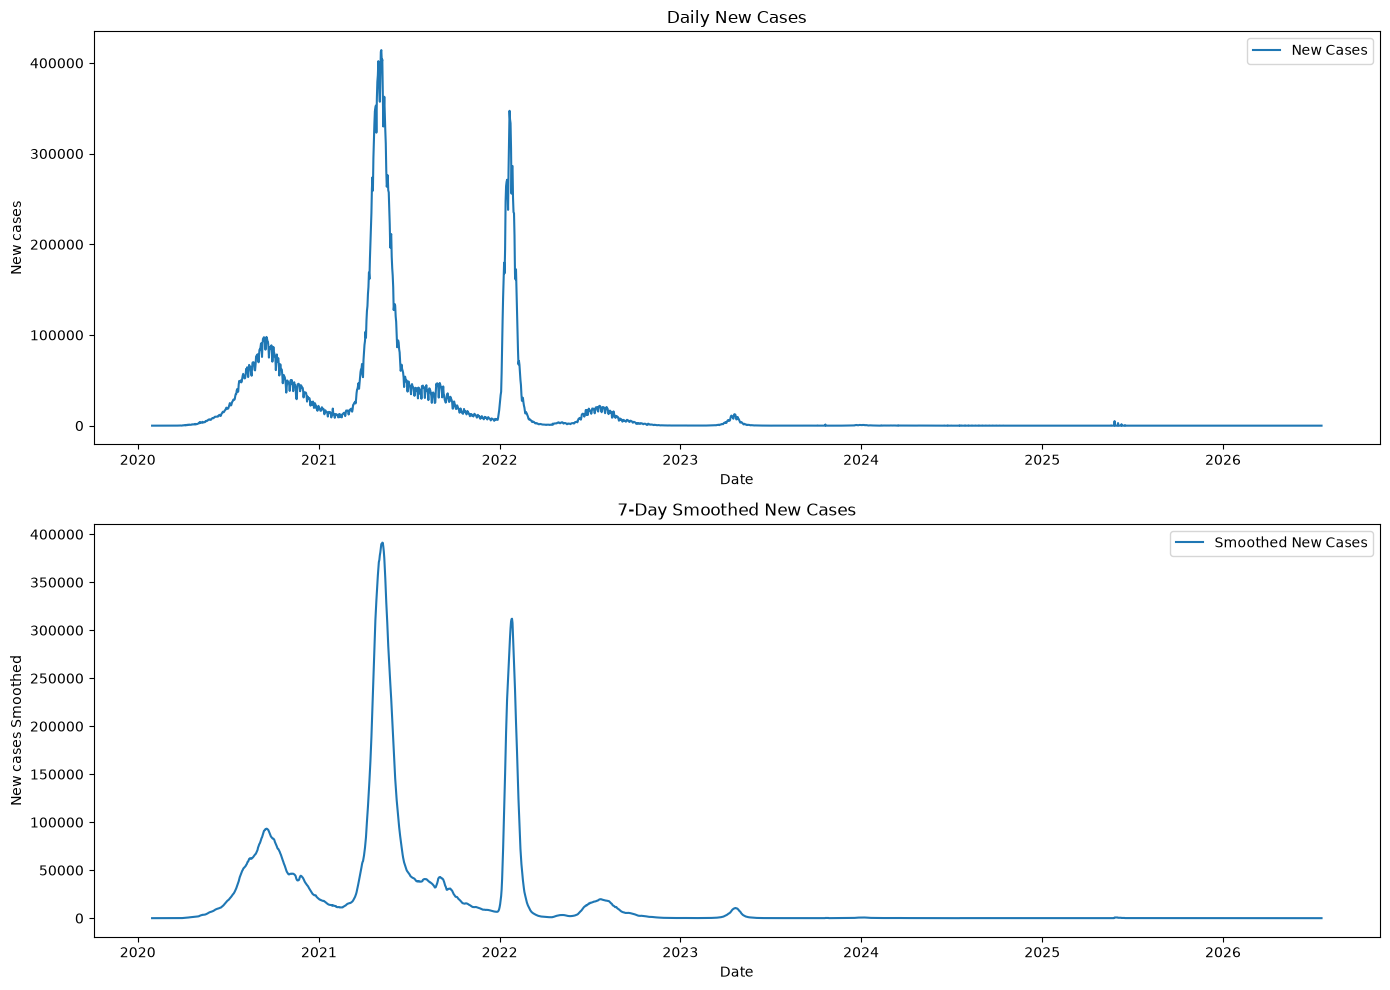

In [46]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# First subplot
sns.lineplot(
    data=df,
    x="date",
    y="new_cases",
    ax=axes[0],
    label="New Cases"
)

axes[0].set_xlabel("Date")
axes[0].set_ylabel("New cases")
axes[0].set_title("Daily New Cases")

# Second subplot
sns.lineplot(
    data=df,
    x="date",
    y="new_cases_smoothed",
    ax=axes[1],
    label="Smoothed New Cases"
)

axes[1].set_xlabel("Date")
axes[1].set_ylabel("New cases Smoothed")
axes[1].set_title("7-Day Smoothed New Cases")

plt.tight_layout()
plt.show()

Using 'Smoothed cases' is much better than 'new cases' because new cases has so much fluctuations but other's trend line is smoothed which is preferred for analysis

There three major spikes in COVID-19 cases throughout:

- 2020: Outbreak with gradual increase
- 2021: Second Wave (Delta Variant), reaching all-time high with sharp increase in cases
- 2022: Third Wave (Omicron Variant), reaching high number of cases within a short time interval


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2363 entries, 243540 to 245902
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       2363 non-null   datetime64[us]
 1   total_cases                2363 non-null   float64       
 2   new_cases                  2363 non-null   float64       
 3   new_cases_smoothed         2363 non-null   float64       
 4   total_deaths               2363 non-null   float64       
 5   new_deaths                 2363 non-null   float64       
 6   new_deaths_smoothed        2363 non-null   float64       
 7   stringency_index           2363 non-null   float64       
 8   positive_rate              2363 non-null   float64       
 9   new_tests_smoothed         2363 non-null   float64       
 10  people_fully_vaccinated    2363 non-null   float64       
 11  new_vaccinations_smoothed  2363 non-null   float64       
 12  reproducti

In [49]:
df.to_csv("df_india.csv", index=False)